# Rental crisis in Portugal — H2: short-term rentals and long-term rental prices

**Hypothesis H2:** municipalities with more short-term rentals (*Alojamento Local*, AL) per 1,000 residents have a higher **long-term rental** price (median €/m² per month of new lease contracts).

| Data | Source | How we get it |
|---|---|---|
| Long-term rental price: median €/m² per month of new lease contracts (last 12 months) | INE – Statistics Portugal | **API** |
| Resident population | INE – Statistics Portugal | **API** |
| Short-term rental registrations (RNAL) | Turismo de Portugal | **Dataset** (CSV download) |

**The story in 5 charts**

1. How many short-term rentals were registered each year?
2. Where? The top 10 municipalities, year by year.
3. Large municipalities have higher long-term rental prices.
4. **Fair comparison:** among municipalities of the same size, do those with more short-term rentals have higher long-term rental prices?
5. Over time: did long-term rental prices rise faster where short-term rentals grew more?


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

In [2]:
# Folders (this notebook lives in the main project folder, next to data/ and figures/)
RAW_FOLDER = Path("data/raw")
CLEAN_FOLDER = Path("data/clean")
FIGURES_FOLDER = Path("figures")
for folder in [RAW_FOLDER, CLEAN_FOLDER, FIGURES_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

HEADERS = {"User-Agent": "data-wrangling-project (student project)"}   # tell the API who we are

**Chart style** – one clean look for every chart in the presentation: white background, one blue accent, grey text for secondary information, no chart borders, and values written on the bars instead of heavy axes.

In [3]:
from matplotlib.colors import LinearSegmentedColormap

# Colours (tested for colour-blind readers)
ACCENT = "#1c5cab"        # dark blue  = main data / "more short-term rentals"
LIGHT_BLUE = "#86b6ef"    # light blue = comparison / "fewer short-term rentals"
INK = "#0b0b0b"           # main text
GREY_TEXT = "#52514e"     # subtitles
MUTED = "#898781"         # axis text and source notes
GRID = "#e1e0d9"          # thin gridlines
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])   # light -> dark for the heatmap

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.size": 11,
    "axes.edgecolor": GRID, "axes.labelcolor": GREY_TEXT,
    "xtick.color": GREY_TEXT, "ytick.color": MUTED, "xtick.labelsize": 11, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.fontsize": 10, "legend.labelcolor": GREY_TEXT,
})


def add_titles(fig, title, subtitle):
    """Bold headline that states the finding + grey subtitle that says what is measured."""
    fig.suptitle(title, x=0.02, y=0.98, ha="left", fontsize=15, fontweight="bold", color=INK)
    fig.text(0.02, 0.905, subtitle, ha="left", fontsize=11, color=GREY_TEXT)


def add_source(fig, text):
    """Small grey note at the bottom left (source, footnotes)."""
    fig.text(0.02, 0.015, text, ha="left", fontsize=8.5, color=MUTED)


def clean_bar_axes(ax):
    """Bar charts: values are written on the bars, so we hide the y axis and keep only the baseline."""
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="x", length=0, pad=8)
    ax.margins(y=0.15)


def euro_label(value_per_m2, flat_m2=80):
    """'9.75 €/m²' plus the monthly rent for an 80 m² flat, so the audience can picture it."""
    return f"{value_per_m2:.2f} €/m²\n≈ {value_per_m2 * flat_m2:,.0f} € / {flat_m2} m²"


def save_chart(fig, file_name):
    """Leave room for titles and source, save in high resolution for slides, then show."""
    fig.tight_layout(rect=(0, 0.05, 1, 0.87))
    fig.savefig(FIGURES_FOLDER / file_name, dpi=200)
    plt.show()

## Data collection

### INE API — long-term rental prices and population

* Documentation: [INE API](https://www.ine.pt/xportal/xmain?xpid=INE&xpgid=ine_api_db)
* Endpoint: `https://www.ine.pt/ine/json_indicador/pindica.jsp?op=2&varcd=<code>&lang=PT`
* Without a period (`Dim1`) the API returns the **most recent period**.
* INE does not publish a rate limit, so we are polite: 1 second pause after each request, and we wait and retry if the server answers **429 (too many requests)**.
* Results are saved in `data/raw/`, so the API is only called once.

| Data | Indicator | Period |
|---|---|---|
| Long-term rental price: median €/m² of new lease contracts, last 12 months | `0014696` | latest (2nd quarter 2026) and 1st quarter 2020 |
| Resident population by municipality | `0012918` | 2025 (most recent year available per municipality) |

In [4]:
INE_URL = "https://www.ine.pt/ine/json_indicador/pindica.jsp"
RENT_INDICATOR = "0014696"
POPULATION_INDICATOR = "0012918"
RENT_START_PERIOD = "S5A20201"     # INE code for the 1st quarter of 2020 (first period available)


def get_json(url, params):
    """Call an API and return the JSON. Retries up to 3 times if the server is busy (HTTP 429)."""
    for attempt in range(1, 4):
        response = requests.get(url, params=params, headers=HEADERS, timeout=60)
        if response.status_code == 429:
            print(f"Too many requests – waiting {attempt * 5} seconds...")
            time.sleep(attempt * 5)
            continue
        response.raise_for_status()   # stops with an error for other problems (404, 500...)
        time.sleep(1)                 # be polite before the next request
        return response.json()
    raise Exception("The API is still busy after 3 attempts.")


def ine_json_to_table(ine_json):
    """INE returns {'Dados': {period: [records]}}. Turn it into one row per period and place."""
    rows = []
    for period, records in ine_json[0]["Dados"].items():
        for record in records:
            record["period"] = period
            rows.append(record)
    return pd.DataFrame(rows)


def load_ine(indicator, file_name, extra_params=None):
    """Read the saved file if it exists; otherwise call the INE API and save the result."""
    file_path = RAW_FOLDER / file_name
    if file_path.exists():
        print(f"Reading the saved file {file_name}")
        return pd.read_csv(file_path, dtype=str)
    print(f"Calling the INE API for indicator {indicator}")
    params = {"op": "2", "varcd": indicator, "lang": "PT", **(extra_params or {})}
    table = ine_json_to_table(get_json(INE_URL, params))
    table.to_csv(file_path, index=False)
    return table

In [5]:
rent_raw = load_ine(RENT_INDICATOR, "ine_rent_raw.csv")
rent_2020_raw = load_ine(RENT_INDICATOR, "ine_rent_2020_raw.csv", {"Dim1": RENT_START_PERIOD})
population_raw = load_ine(POPULATION_INDICATOR, "ine_population_raw.csv", {"Dim3": "T", "Dim4": "T"})  # T = total

print("Long-term rent (latest):", rent_raw["period"].iloc[0])
print("Long-term rent (start): ", rent_2020_raw["period"].iloc[0])
print("Population:   ", population_raw["period"].iloc[0])

Reading the saved file ine_rent_raw.csv
Reading the saved file ine_rent_2020_raw.csv
Reading the saved file ine_population_raw.csv
Long-term rent (latest): 2.º Trimestre de 2026
Long-term rent (start):  1.º Trimestre de 2020
Population:    2025


### RNAL dataset — short-term rental registrations

Download the CSV from the [Turismo de Portugal open-data portal](https://dadosabertos.turismodeportugal.pt/datasets/estabelecimentos-de-alojamento-local) and save it as `data/raw/rnal_small.csv`.

In [6]:
rnal_raw = pd.read_csv(RAW_FOLDER / "rnal_small.csv", dtype=str, encoding="utf-8-sig")  # utf-8-sig removes a hidden character
rnal_raw.head(3)

,NrRNAL,DataRegisto,DTMNFR,Concelho
0,1,2014/12/03 09:47:03+00,081005,Olhão
1,2,2013/07/30 00:00:00+00,081005,Olhão
2,3,2014/11/27 08:39:27+00,081412,Tavira


## 3. Cheking the data

In [7]:
def quick_check(df, name):
    print(f"--- {name} ---")
    print("Rows, columns:", df.shape)
    print("Duplicated rows:", df.duplicated().sum())
    missing = df.isna().sum()
    print("Columns with missing values:", missing[missing > 0].to_dict())
    print()


quick_check(rent_raw, "INE long-term rent")
quick_check(population_raw, "INE population")
quick_check(rnal_raw, "RNAL")

--- INE long-term rent ---
Rows, columns: (638, 7)
Duplicated rows: 0
Columns with missing values: {'valor': 148, 'sinal_conv': 490, 'sinal_conv_desc': 490}

--- INE population ---
Rows, columns: (347, 9)
Duplicated rows: 0
Columns with missing values: {}

--- RNAL ---
Rows, columns: (111852, 4)
Duplicated rows: 0
Columns with missing values: {}



In [8]:
# INE mixes geographic levels. The length of 'geocod' tells us which one:
# 1-3 characters = Portugal and regions, 7 = municipality, 9 = parish
rent_raw["geocod"].str.len().value_counts()

geocod
7    308
9    291
3     26
2     10
1      3
Name: count, dtype: int64

**RNAL columns we use**

| Column | Meaning |
|---|---|
| `NrRNAL` | registration number |
| `DataRegisto` | registration date (text like `2014/12/03 09:47:03+00`) |
| `DTMNFR` | parish code – **the first 4 digits are the municipality code**, the same as the last 4 digits of INE's `geocod` |
| `Concelho` | municipality name |

**Cleaning plan**

| Problem | Technique |
|---|---|
| Many columns we don't need | drop columns |
| INE mixes country, regions, municipalities and parishes | filter rows (mainland municipalities) |
| Numbers and dates stored as text | convert types |
| Municipality code inside longer codes | string slicing (`.str[:4]`, `.str[-4:]`) |
| Municipalities without a long-term rent value | drop missing values (and report them) |
| Possible repeated registrations | remove duplicates |

We merge the datasets on the **municipality code**, not on names, so spelling differences cannot break the merge.

## Cleaning

In [9]:
def keep_mainland_municipalities(df):
    """Municipalities have a 7-character geocod; mainland Portugal codes start with '1'."""
    return df[(df["geocod"].str.len() == 7) & (df["geocod"].str.startswith("1"))].copy()


def clean_ine(df, value_name):
    """Main cleaning function for an INE table: one row per mainland municipality."""
    df = keep_mainland_municipalities(df)
    if "dim_3" in df.columns:                                     # population: keep totals only
        df = df[(df["dim_3"] == "T") & (df["dim_4"] == "T")]
    df[value_name] = pd.to_numeric(df["valor"], errors="coerce")  # text -> number
    df["municipality_code"] = df["geocod"].str[-4:]               # last 4 digits = municipality
    df = df.rename(columns={"geodsg": "municipality"})
    return df[["municipality_code", "municipality", value_name]]


def clean_rnal(df):
    """Main cleaning function for RNAL: one row per registered short-term rental."""
    df = df[["NrRNAL", "DataRegisto", "DTMNFR", "Concelho"]].copy()     # drop unused columns
    df = df.drop_duplicates(subset="NrRNAL")                            # one row per registration
    df = df.dropna(subset=["DTMNFR"])
    df["municipality_code"] = df["DTMNFR"].str.strip().str[:4]          # parish code -> municipality code
    df["registration_date"] = pd.to_datetime(df["DataRegisto"].str[:10], format="%Y/%m/%d", errors="coerce")
    df["year"] = df["registration_date"].dt.year
    df = df.rename(columns={"Concelho": "municipality"})
    return df[["municipality_code", "municipality", "registration_date", "year"]]


rent = clean_ine(rent_raw, "long_term_rent")
rent_2020 = clean_ine(rent_2020_raw, "long_term_rent_2020")
population = clean_ine(population_raw, "population")
rnal = clean_rnal(rnal_raw)

print("Municipalities:", len(rent), "| without a long-term rent value:", rent["long_term_rent"].isna().sum())
print("Short-term rental registrations:", len(rnal))

Municipalities: 278 | without a long-term rent value: 41
Short-term rental registrations: 111852


**Limitation:** RNAL counts *registrations* that exist today. Some places may not be rented out any more, and places that closed in the past are not in the file.

## Combining the data

One row per municipality with: long-term rent (now and in 2020), population and number of short-term rentals.

In [10]:
str_count = rnal.groupby("municipality_code").size().rename("str_units")
new_str_count = (rnal[rnal["registration_date"] >= "2020-04-01"]          # registered after the 1Q 2020 long-term rent period
                 .groupby("municipality_code").size().rename("new_str_units"))

h2 = population.merge(rent[["municipality_code", "long_term_rent"]], on="municipality_code")
h2 = h2.merge(rent_2020[["municipality_code", "long_term_rent_2020"]], on="municipality_code", how="left")
h2 = h2.join(str_count, on="municipality_code").join(new_str_count, on="municipality_code")
h2[["str_units", "new_str_units"]] = h2[["str_units", "new_str_units"]].fillna(0)  # not in RNAL = 0

no_rent = h2["long_term_rent"].isna()
print(f"{no_rent.sum()} of {len(h2)} municipalities have no long-term rent value (too few contracts; "
      f"median population {h2.loc[no_rent, 'population'].median():,.0f}) -> removed")
h2 = h2[~no_rent].copy()

41 of 278 municipalities have no long-term rent value (too few contracts; median population 4,362) -> removed


**New fields**

* `str_per_1000` – short-term rentals per 1,000 residents
* `size_group` – **Small** (up to 50,000 residents) or **Large** (more than 50,000 residents)
* `str_level` – **More STR** or **Fewer STR** than the middle (median) municipality **of the same size**
* `rent_growth_pct` – long-term rent growth from 1Q 2020 to today, and `new_str_per_1000` – short-term rentals registered since April 2020 per 1,000 residents

In [11]:
def more_or_fewer(values):
    """Label each value 'More STR' or 'Fewer STR' compared with the median of its group."""
    return np.where(values > values.median(), "More STR", "Fewer STR")


h2["str_per_1000"] = h2["str_units"] / h2["population"] * 1000
h2["new_str_per_1000"] = h2["new_str_units"] / h2["population"] * 1000
h2["rent_growth_pct"] = (h2["long_term_rent"] / h2["long_term_rent_2020"] - 1) * 100
h2["size_group"] = pd.cut(h2["population"], bins=[0, 50_000, float("inf")], labels=["Small", "Large"])
h2["str_level"] = h2.groupby("size_group", observed=True)["str_per_1000"].transform(more_or_fewer)

h2.to_csv(CLEAN_FOLDER / "h2_clean.csv", index=False)
print("Municipalities in the analysis:", len(h2))
h2["size_group"].value_counts()

Municipalities in the analysis: 237


size_group
Small    175
Large     62
Name: count, dtype: int64

## Analysis

### Chart 1 – Short-term rental registrations per year (last 10 years)

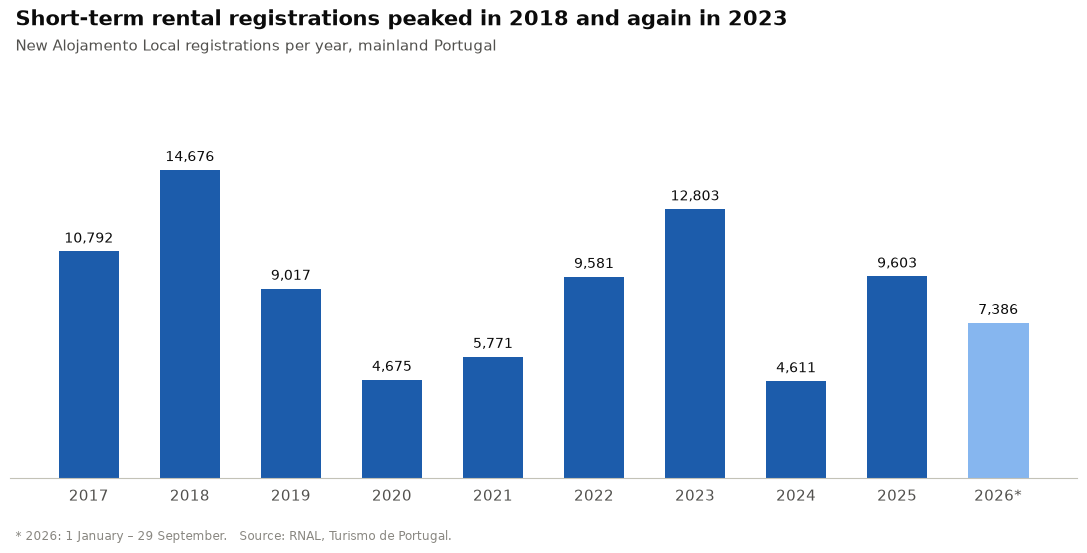

In [12]:
last_date = rnal["registration_date"].max()
last_year = last_date.year
YEARS = list(range(last_year - 9, last_year + 1))          # last 10 years

per_year = rnal[rnal["year"].isin(YEARS)].groupby("year").size().reindex(YEARS, fill_value=0)
peak_years = sorted(per_year.nlargest(2).index)          # the two busiest years
labels = [f"{year}*" if year == last_year else str(year) for year in YEARS]
colors = [LIGHT_BLUE if year == last_year else ACCENT for year in YEARS]   # incomplete year in lighter blue

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(labels, per_year.values, color=colors, width=0.6)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in per_year.values], padding=4, fontsize=10, color=INK)
clean_bar_axes(ax)
add_titles(fig, f"Short-term rental registrations peaked in {peak_years[0]} and again in {peak_years[1]}",
           "New Alojamento Local registrations per year, mainland Portugal")
add_source(fig, f"* {last_year}: 1 January – {last_date:%d %B}.   Source: RNAL, Turismo de Portugal.")
save_chart(fig, "h2_1_registrations_per_year.png")

### Chart 2 – Top 10 municipalities: new registrations per year

In [13]:
def top_municipalities_per_year(rnal, years, n=10):
    """Table with the n municipalities with most registrations in `years`, one column per year."""
    recent = rnal[rnal["year"].isin(years)]
    top_names = recent["municipality"].value_counts().head(n).index
    table = pd.crosstab(recent["municipality"], recent["year"])      # count per municipality and year
    table = table.reindex(index=top_names, columns=years, fill_value=0)
    table["Total"] = table.sum(axis=1)
    return table


top_10 = top_municipalities_per_year(rnal, YEARS, n=10)
top_10

year,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,Total
municipality,,,,,,,,,,,
Porto,1184,1346,971,475,723,1607,713,216,834,562,8631
Lisboa,2054,3714,1160,254,436,571,163,28,30,109,8519
Albufeira,763,945,626,405,499,807,1080,298,703,513,6639
Loulé,643,812,601,299,326,542,839,170,515,527,5274
Portimão,527,733,439,275,291,471,802,66,484,375,4463
Lagos,413,457,351,199,193,459,701,122,405,468,3768
Tavira,222,337,238,160,124,244,410,88,249,182,2254
Cascais,225,356,241,116,85,239,435,62,231,126,2116
Silves,222,289,199,95,102,247,411,105,224,206,2100


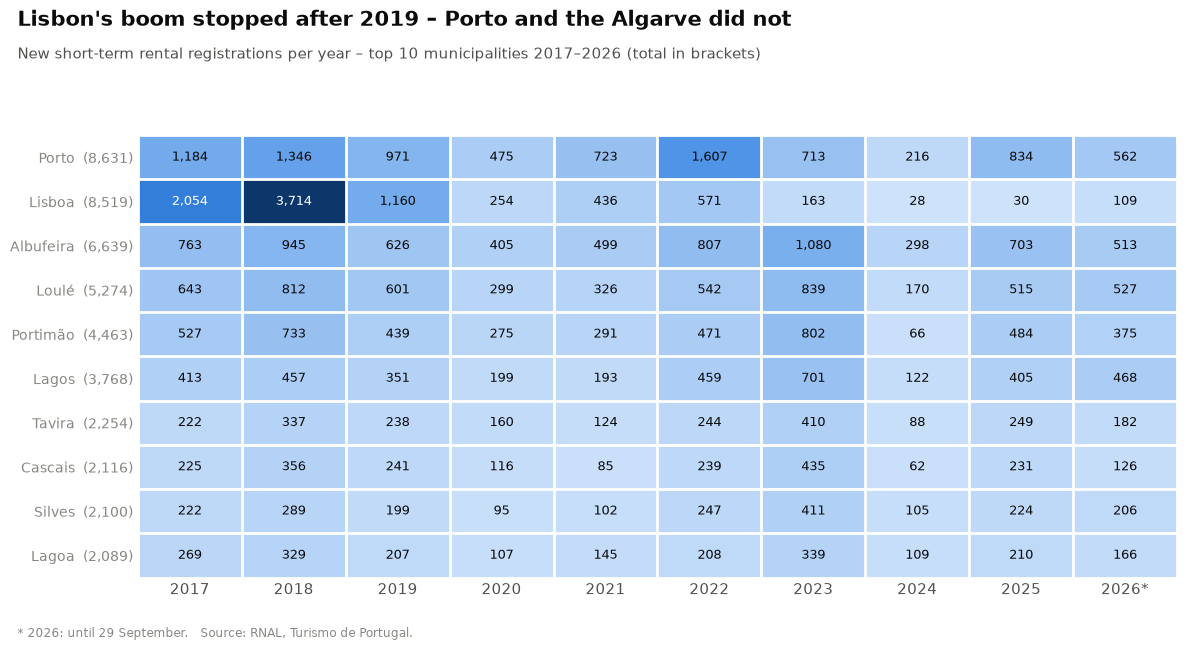

In [14]:
yearly = top_10[YEARS]
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.imshow(yearly, cmap=BLUE_RAMP, aspect="auto")
ax.set_xticks(range(len(YEARS)), labels)
ax.set_yticks(range(len(yearly)), [f"{name}  ({total:,})" for name, total in top_10["Total"].items()])
ax.tick_params(length=0)
ax.set_xticks(np.arange(-0.5, len(YEARS)), minor=True)       # white lines between the cells
ax.set_yticks(np.arange(-0.5, len(yearly)), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)
for row in range(yearly.shape[0]):                          # the number in each cell
    for col in range(yearly.shape[1]):
        value = yearly.iloc[row, col]
        dark_cell = value > yearly.values.max() * 0.45
        ax.text(col, row, f"{value:,}", ha="center", va="center", fontsize=9,
                color="white" if dark_cell else INK)
add_titles(fig, "Lisbon's boom stopped after 2019 – Porto and the Algarve did not",
           f"New short-term rental registrations per year – top 10 municipalities {YEARS[0]}–{last_year} (total in brackets)")
add_source(fig, f"* {last_year}: until {last_date:%d %B}.   Source: RNAL, Turismo de Portugal.")
save_chart(fig, "h2_2_top10_per_year.png")

### Chart 3 – Large municipalities have higher long-term rental prices

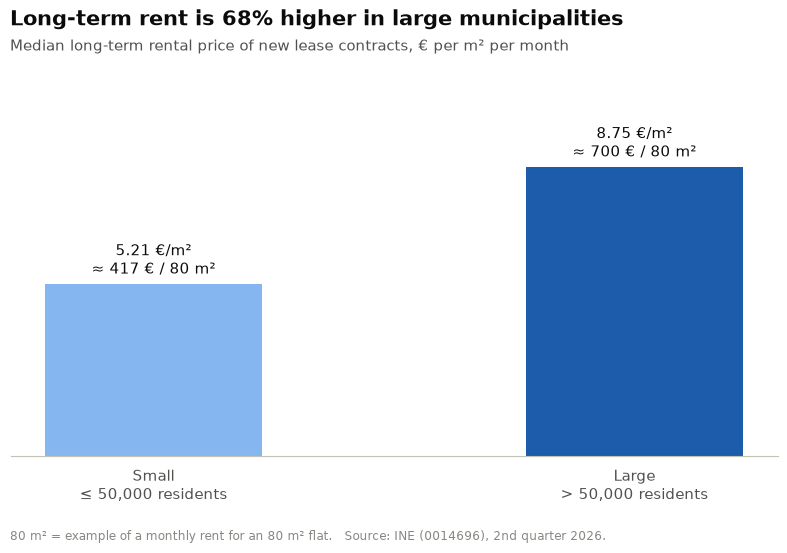

In [15]:
rent_by_size = h2.groupby("size_group", observed=True)["long_term_rent"].median()
size_gap = (rent_by_size["Large"] / rent_by_size["Small"] - 1) * 100

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(["Small\n≤ 50,000 residents", "Large\n> 50,000 residents"], rent_by_size.values,
              color=[LIGHT_BLUE, ACCENT], width=0.45)
ax.bar_label(bars, labels=[euro_label(v) for v in rent_by_size.values], padding=4, fontsize=11, color=INK)
clean_bar_axes(ax)
add_titles(fig, f"Long-term rent is {size_gap:.0f}% higher in large municipalities",
           "Median long-term rental price of new lease contracts, € per m² per month")
add_source(fig, "80 m² = example of a monthly rent for an 80 m² flat.   Source: INE (0014696), 2nd quarter 2026.")
save_chart(fig, "h2_3_long_term_rent_by_size.png")

Small municipalities often have **many** short-term rentals per resident (e.g. Aljezur, Vila do Bispo) but **low** long-term rental prices. If we compare all municipalities together, this hides the effect we are looking for. So we compare municipalities **of the same size** →

### Chart 4 – Fair comparison: same size, more vs fewer short-term rentals

Long-term rental price (median €/m² per month):


str_level,Fewer STR,More STR,Difference %
size_group,,,
Small,5.26,5.09,-3.32
Large,6.92,9.75,40.90


Same values as a monthly long-term rent for a 80 m² flat (€):


str_level,Fewer STR,More STR
size_group,,
Small,421.0,407.0
Large,554.0,780.0


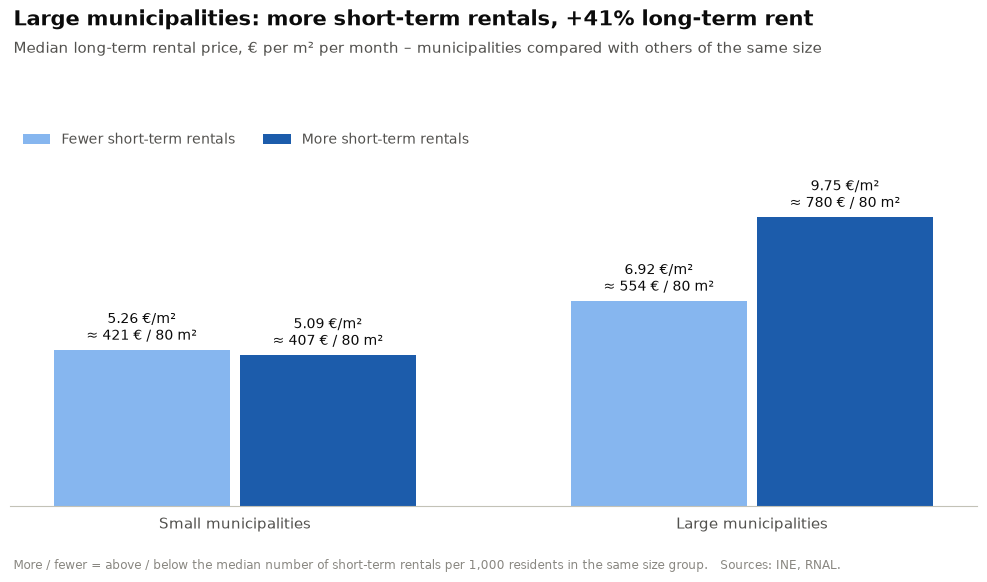

In [16]:
def grouped_bar_chart(table, value_labels, title, subtitle, source, file_name,
                      legend=("Fewer short-term rentals", "More short-term rentals")):
    """Two bars (fewer / more short-term rentals) for each size group, with values on top."""
    x = np.arange(len(table))
    fig, ax = plt.subplots(figsize=(10, 5.8))
    for offset, column, color, name in [(-0.18, table.columns[0], LIGHT_BLUE, legend[0]),
                                        (0.18, table.columns[1], ACCENT, legend[1])]:
        bars = ax.bar(x + offset, table[column], width=0.34, color=color, label=name)
        ax.bar_label(bars, labels=[value_labels(v) for v in table[column]], padding=4, fontsize=10, color=INK)
    ax.set_xticks(x, [f"{size} municipalities" for size in table.index.astype(str)])
    clean_bar_axes(ax)
    ax.legend(loc="lower left", frameon=False, ncol=2, bbox_to_anchor=(0, 1.0))
    ax.margins(y=0.2)
    add_titles(fig, title, subtitle)
    add_source(fig, source)
    save_chart(fig, file_name)


rent_comparison = pd.pivot_table(h2, values="long_term_rent", index="size_group", columns="str_level",
                                 aggfunc="median", observed=True)
rent_comparison["Difference %"] = (rent_comparison["More STR"] / rent_comparison["Fewer STR"] - 1) * 100
print("Long-term rental price (median €/m² per month):")
display(rent_comparison.round(2))

FLAT_SIZE_M2 = 80
print(f"Same values as a monthly long-term rent for a {FLAT_SIZE_M2} m² flat (€):")
display((rent_comparison[["Fewer STR", "More STR"]] * FLAT_SIZE_M2).round(0))

large_gap = rent_comparison.loc["Large", "Difference %"]
grouped_bar_chart(
    rent_comparison[["Fewer STR", "More STR"]], euro_label,
    f"Large municipalities: more short-term rentals, {large_gap:+.0f}% long-term rent",
    "Median long-term rental price, € per m² per month – municipalities compared with others of the same size",
    "More / fewer = above / below the median number of short-term rentals per 1,000 residents in the same size group.   "
    "Sources: INE, RNAL.",
    "h2_4_long_term_rent_same_size.png")

### Chart 5 – Over time: did long-term rental prices rise faster where short-term rentals grew more?

Median long-term rent growth since 1Q 2020, all municipalities: 71%


new_str_level,Fewer STR,More STR
size_group,,
Small,73.7,64.2
Large,75.3,69.8


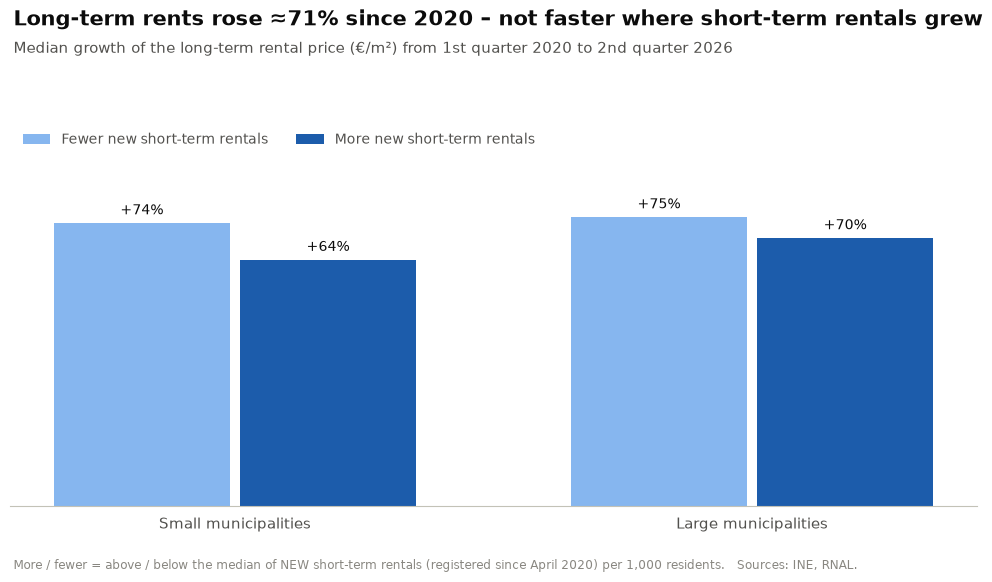

In [17]:
h2["new_str_level"] = h2.groupby("size_group", observed=True)["new_str_per_1000"].transform(more_or_fewer)
growth = h2.dropna(subset=["long_term_rent_2020"])               # need a long-term rent value in 2020 too

growth_comparison = pd.pivot_table(growth, values="rent_growth_pct", index="size_group",
                                   columns="new_str_level", aggfunc="median", observed=True)
overall_growth = growth["rent_growth_pct"].median()
print(f"Median long-term rent growth since 1Q 2020, all municipalities: {overall_growth:.0f}%")
display(growth_comparison.round(1))

faster = (growth_comparison["More STR"] > growth_comparison["Fewer STR"]).any()
grouped_bar_chart(
    growth_comparison[["Fewer STR", "More STR"]], lambda v: f"+{v:.0f}%",
    f"Long-term rents rose ≈{overall_growth:.0f}% since 2020 – "
    + ("faster where short-term rentals grew" if faster else "not faster where short-term rentals grew"),
    "Median growth of the long-term rental price (€/m²) from 1st quarter 2020 to 2nd quarter 2026",
    "More / fewer = above / below the median of NEW short-term rentals (registered since April 2020) per 1,000 residents.   "
    "Sources: INE, RNAL.",
    "h2_5_long_term_rent_growth.png",
    legend=("Fewer new short-term rentals", "More new short-term rentals"))

### Supporting table – municipalities with the most short-term rentals per resident

In [18]:
(h2.sort_values("str_per_1000", ascending=False)
   .head(10)[["municipality", "population", "str_units", "str_per_1000", "long_term_rent"]]
   .round(1))

,municipality,population,str_units,str_per_1000,long_term_rent
81,Aljezur,7456,1406,188.6,9.0
74,Vila do Bispo,7078,1180,166.7,9.4
233,Albufeira,63375,10491,165.5,12.2
206,Lagos,40729,4775,117.2,12.8
189,Lagoa,28548,3260,114.2,9.9
195,Tavira,33006,2998,90.8,11.5
250,Loulé,94447,7333,77.6,12.3
150,Nazaré,17067,1283,75.2,9.0
242,Portimão,78125,5724,73.3,11.7
83,Castro Marim,7570,496,65.5,9.2


## Conclusions

*Numbers from our run on 29 September 2026 (long-term rent: 2nd quarter 2026 vs 1st quarter 2020, population 2025, RNAL up to 29 September 2026). Check them against the tables above if you re-run with new data.*

*Reminder: all €/m² values are **monthly long-term rents per square metre** from signed contracts (INE), not tourist prices.*

**1. Short-term rentals kept growing (Charts 1–2).** Thousands of new AL are registered every year, with peaks in **2018 (≈14,700)** and **2023 (≈12,800)**. Growth is concentrated in **Porto, Lisboa and the Algarve** (Albufeira, Loulé, Portimão, Lagos). In Lisboa, new registrations almost stopped after 2019 (from 3,714 in 2018 to fewer than 200 per year since 2023).

**2. Size explains most of the long-term rental price (Chart 3).** Median long-term rent: Small municipalities **5.21 €/m²** (≈ 417 €/month for 80 m²), Large municipalities **8.75 €/m²** (≈ 700 €/month for 80 m²).

**3. Same size, more short-term rentals → higher long-term rental price, but only in large municipalities (Chart 4).**

| Size | Fewer STR | More STR | Difference | 80 m² flat per month |
|---|---|---|---|---|
| Small (≤ 50,000 residents, 175 municipalities) | 5.26 €/m² | 5.09 €/m² | −3% | ≈ 421 € vs 407 € |
| Large (> 50,000 residents, 62 municipalities) | 6.92 €/m² | **9.75 €/m²** | **+41%** | ≈ 554 € vs **780 €** |

**4. Since 2020 long-term rental prices rose everywhere – not faster where short-term rentals grew (Chart 5).** The median long-term rent went up **≈ +71%** between 1Q 2020 and 2Q 2026. Municipalities with more new short-term rentals did **not** see faster growth (small: ≈ 63% vs 74%; large: ≈ 70% vs 75%).

### Answer to H2
**Partly supported.** In large municipalities, those with more short-term rentals have clearly higher long-term rental prices (+41%). In small municipalities there is no difference, and long-term rental prices rose by about 70% almost everywhere, whether short-term rentals grew or not. **Short-term rentals are one part of the story, not the main cause of the rental crisis.**

**Correlation is not causation:** touristy and expensive places share other causes (jobs, coast, foreign demand, little new housing).

**Limitations**
* RNAL lists registrations that exist today (not necessarily active, and closed ones are missing).
* 41 small municipalities have no INE long-term rent value (too few contracts).
* INE values are signed contracts (lower than advertised prices) and a 12-month median.
* Different dates: long-term rent 2Q 2026, population 2025.